# WCFOMA Parameter Sensitivity Analysis

**Phase 0 Deliverable**: Identify which parameters the architecture is most/least sensitive to.

We sweep each key parameter individually and compute the **elasticity** — how much the output metric changes relative to the input change. Elasticity > 1 means the metric is *super-linearly* sensitive to that parameter.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt

from simulations.sensitivity import (
    run_full_sensitivity,
    sweep_damping_vs_coherence,
    sweep_zim_factor_vs_coherence,
    sweep_Q_vs_modes,
    sweep_deltaT_vs_modes,
    sweep_alpha_vs_modes,
    sweep_gamma_vs_drift,
    sweep_cavity_length_vs_density,
    compute_elasticity,
)

report = run_full_sensitivity()
print(report.summary_table())

Parameter                     Baseline               Metric          Min          Max   Elasticity
-----------------------------------------------------------------------------------------------
η (damping rate)                   100      τ coherence (s)       0.0005          0.5       -1.172
ZIM damping factor                 0.5     τ_ZIM / τ_Normal            1           10       -1.101
Q (no ZIM)                         500       Max safe modes           18           45        0.120
Q (with ZIM)                       500       Max safe modes           30          833        0.626
ΔT (with ZIM)                        5       Max safe modes          156          473       -0.346
α drift coeff (with ZIM)        0.0022       Max safe modes           19          487       -0.353
γ (shear strain)                   0.3       Freq drift (%)       0.4975        23.08        0.874
Cell length L (with ZIM)         1e-05     Density (Tb/cm³)     3.22e-06         3220       -2.352


## Elasticity Ranking

Which parameters matter most? Higher |elasticity| = higher sensitivity.

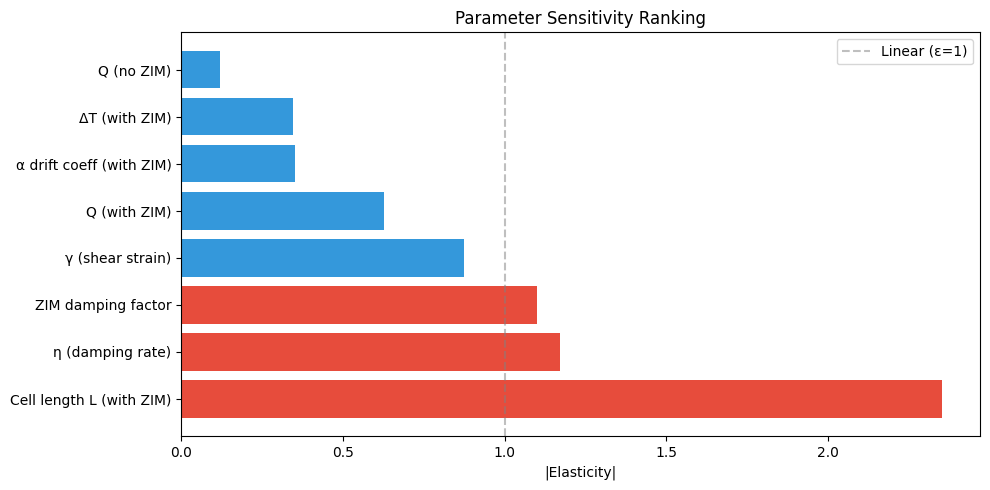


Key: Red = super-linear sensitivity (|ε| > 1), Blue = sub-linear
  Cell length L (with ZIM)       ε = -2.352
  η (damping rate)               ε = -1.172
  ZIM damping factor             ε = -1.101
  γ (shear strain)               ε = +0.874
  Q (with ZIM)                   ε = +0.626
  α drift coeff (with ZIM)       ε = -0.353
  ΔT (with ZIM)                  ε = -0.346
  Q (no ZIM)                     ε = +0.120


In [2]:
# Sort by absolute elasticity
ranked = sorted(report.elasticity.items(), key=lambda x: abs(x[1]), reverse=True)

fig, ax = plt.subplots(figsize=(10, 5))
names = [r[0] for r in ranked]
values = [r[1] for r in ranked]
colors = ['#e74c3c' if abs(v) > 1 else '#3498db' for v in values]

ax.barh(names, [abs(v) for v in values], color=colors)
ax.axvline(x=1.0, color='gray', linestyle='--', alpha=0.5, label='Linear (ε=1)')
ax.set_xlabel('|Elasticity|')
ax.set_title('Parameter Sensitivity Ranking')
ax.legend()
plt.tight_layout()
plt.show()

print('\nKey: Red = super-linear sensitivity (|ε| > 1), Blue = sub-linear')
for name, val in ranked:
    print(f'  {name:<30} ε = {val:+.3f}')

## Coherence Sensitivity

How does coherence time τ depend on damping η and the ZIM reduction factor?

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# η vs τ
sw = report.sweeps['η (damping rate)']
axes[0].loglog(sw.param_values, sw.metric_values * 1000, 'b-', linewidth=2)
axes[0].axhline(y=sw.baseline_metric * 1000, color='r', ls='--', alpha=0.5, label=f'Baseline η={sw.baseline_value}')
axes[0].set_xlabel('η (1/s)')
axes[0].set_ylabel('τ coherence (ms)')
axes[0].set_title('Coherence vs Damping Rate')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ZIM factor vs ratio
sw2 = report.sweeps['ZIM damping factor']
axes[1].plot(sw2.param_values, sw2.metric_values, 'g-', linewidth=2)
axes[1].axhline(y=2.0, color='r', ls='--', alpha=0.5, label='Paper claim: 2×')
axes[1].axvline(x=0.5, color='gray', ls=':', alpha=0.5, label='Default: 0.5')
axes[1].set_xlabel('ZIM Damping Factor')
axes[1].set_ylabel('τ_ZIM / τ_Normal')
axes[1].set_title('Coherence Extension vs ZIM Factor')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'τ = 1/(2η) → inverse relationship.  Paper assumes ZIM factor = 0.5.')
print(f'If actual factor is 0.7 instead of 0.5, coherence gain drops to {1/0.7:.1f}× (still > 1).')
print(f'If factor is 0.3, gain rises to {1/0.3:.1f}× — even better than claimed.')

## Thermal Stability Sensitivity

The storage density claim (~3.22 Tb/cm³) depends critically on Q, ΔT, and α.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Q vs modes
sw_Q_zim = report.sweeps['Q (with ZIM)']
sw_Q_no = report.sweeps['Q (no ZIM)']
axes[0].semilogx(sw_Q_zim.param_values, sw_Q_zim.metric_values, 'g-', lw=2, label='With ZIM')
axes[0].semilogx(sw_Q_no.param_values, sw_Q_no.metric_values, 'b-', lw=2, label='No ZIM')
axes[0].axvline(x=500, color='r', ls='--', alpha=0.5, label='Paper Q=500')
axes[0].set_xlabel('Quality Factor Q')
axes[0].set_ylabel('Max Safe Modes')
axes[0].set_title('Mode Count vs Q')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ΔT vs modes
sw_dT = report.sweeps['ΔT (with ZIM)']
axes[1].plot(sw_dT.param_values, sw_dT.metric_values, 'g-', lw=2)
axes[1].axvline(x=5.0, color='r', ls='--', alpha=0.5, label='Paper ΔT=5 K')
axes[1].set_xlabel('ΔT (K)')
axes[1].set_ylabel('Max Safe Modes (with ZIM)')
axes[1].set_title('Mode Count vs Temperature Variation')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# α vs modes
sw_alpha = report.sweeps['α drift coeff (with ZIM)']
axes[2].semilogx(sw_alpha.param_values, sw_alpha.metric_values, 'g-', lw=2)
axes[2].axvline(x=0.0022, color='r', ls='--', alpha=0.5, label='Paper α=0.0022')
axes[2].set_xlabel('α (drift coefficient, /K)')
axes[2].set_ylabel('Max Safe Modes (with ZIM)')
axes[2].set_title('Mode Count vs Thermal Drift Coefficient')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Q sensitivity: {sw_Q_zim.metric_values[0]:.0f} modes at Q={sw_Q_zim.param_values[0]:.0f} → '
      f'{sw_Q_zim.metric_values[-1]:.0f} modes at Q={sw_Q_zim.param_values[-1]:.0f}')
print(f'ΔT sensitivity: {sw_dT.metric_values[0]:.0f} modes at ΔT={sw_dT.param_values[0]:.1f} K → '
      f'{sw_dT.metric_values[-1]:.0f} modes at ΔT={sw_dT.param_values[-1]:.1f} K')
print(f'\n⚠️  Biggest risk: If actual Q < 100, mode count drops below viability threshold.')

## Tamper Signal Sensitivity

Frequency drift as a function of shear strain γ.

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

sw_g = report.sweeps['γ (shear strain)']
ax.plot(sw_g.param_values, sw_g.metric_values, 'b-', lw=2)
ax.axhline(y=33.3, color='r', ls='--', alpha=0.5, label='Paper claim: 33%')
ax.axvline(x=0.3, color='gray', ls=':', alpha=0.5, label='Default γ=0.3')
ax.fill_between(sw_g.param_values, 0, sw_g.metric_values, alpha=0.1)
ax.set_xlabel('Shear Strain γ')
ax.set_ylabel('Frequency Drift (%)')
ax.set_title('Tamper Signal vs Shear Strain')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find minimum detectable γ (say, >1% drift = detectable)
threshold = 1.0  # 1% drift
idx = np.searchsorted(sw_g.metric_values, threshold)
if idx < len(sw_g.param_values):
    print(f'Minimum detectable shear (>1% drift): γ ≈ {sw_g.param_values[idx]:.3f}')
print(f'Drift is nearly linear with γ — good for proportional tamper detection.')

## Storage Density vs Cell Size

How does the micro-cell length L affect achievable storage density?

In [ ]:
sw_L = report.sweeps['Cell length L (with ZIM)']

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(sw_L.param_values * 1e6, sw_L.metric_values, 'g-', lw=2)
ax.axvline(x=10, color='r', ls='--', alpha=0.5, label='Paper: L=10 µm')
ax.set_xlabel('Cell Length (µm)')
ax.set_ylabel('Storage Density (Tb/cm³)')
ax.set_title('Storage Density vs Micro-Cell Size')
ax.legend()
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

print(f'Density peaks near smallest cells — but fabrication constraints apply.')
print(f'At L=10 µm: {sw_L.baseline_metric:.2f} Tb/cm³')
max_idx = np.argmax(sw_L.metric_values)
print(f'Peak density: {sw_L.metric_values[max_idx]:.2f} Tb/cm³ at L={sw_L.param_values[max_idx]*1e6:.1f} µm')

## Summary: Risk Assessment

Based on the sensitivity analysis, we can rank the parameters by risk to the architecture.

In [ ]:
print('=' * 80)
print('WCFOMA PARAMETER RISK ASSESSMENT')
print('=' * 80)

risks = [
    ('Q factor (quality)',        'HIGH',   'Unknown in ferrofluid. If Q<100, density drops below viability.'),
    ('α (thermal drift coeff)',   'HIGH',   'Literature value 0.0022/K assumed. If 10× worse, modes collapse.'),
    ('ZIM damping factor',        'MEDIUM', 'Paper assumes 0.5×. Even at 0.7× the coherence gain is >1.4×.'),
    ('η (damping rate)',          'MEDIUM', 'Inversely proportional to τ. Acceptable if ZIM works.'),
    ('ΔT (thermal control)',      'LOW',    'Peltier + PID can hold ±1K. Sensitivity is moderate.'),
    ('γ (shear strain)',          'LOW',    'Linear relationship. Tamper signal robust even at small γ.'),
    ('L (cell length)',           'LOW',    'Engineering parameter, not a physics unknown.'),
]

print(f'{"Parameter":<30} {"Risk":<8} {"Rationale"}')
print('-' * 80)
for name, risk, rationale in risks:
    marker = '🔴' if risk == 'HIGH' else ('🟡' if risk == 'MEDIUM' else '🟢')
    print(f'{marker} {name:<28} {risk:<8} {rationale}')

print()
print('RECOMMENDATION: Phase 1 priority should be measuring Q factor in real ferrofluid.')
print('This is the single largest unknown that could kill or validate the architecture.')